# Uproot Raw Tutorial

Introduction blablabla

#### Make sure your endpoint token `servicex.yaml` is in the running path

In [1]:
import os
assert os.path.exists('servicex.yaml'), 'servicex.yaml not found in working directory'

## Example 1: Retrieving CP Ntuples sotred in the GRID
### Declare your dataset
The following example uses a Rucio dataset containing CP nutples.

In [2]:
from servicex import dataset, query, deliver

In [3]:
my_DS="user.acordeir:michigan-tutorial.displaced-signal.root" 
request_DS=dataset.Rucio(my_DS)

### Building an uproot query. 
This query will define the task the ServiceX workers perform on the selected dataset.

A code is generated on the server using your minimal input for:

1) TTree name (or Rntuple) to open
2) The filtering for branch selection in the tree
3) The event cuts to be applied as masks on the arrays 

Finally, the workers execute the generated code with `uproot` (file reading/writting) and `awkward` (array handling) to thin and skim files before outputing a result that is automatically downloaded on your side. 

In [4]:
#1 the reco tree from TopCP produced files
tree_name = "reco"

#2 truth signal branches and reco jet variables
branch_selection = [
        "truth_alp_decayVtxX",
        "truth_alp_decayVtxY",
        "truth_alp_pt",
        "truth_alp_eta",
        "jet_EMFrac_NOSYS", 
        "jet_pt_NOSYS" ]

#3 Deciding the cuts in one string with conditions
# Uses awkward array expressions, e.g., count(), num(), all(), any(), max(), abs()...
# A single reco jet, bsm signal pt > 20 GeV & in the inner barrel  
array_mask='(num(jet_pt_NOSYS)<2) & any((truth_alp_pt>20) & (abs(truth_alp_eta)<0.8))'

Select the `UprootRaw` query type from the ServiceX `query` object

In [5]:
my_uproot_query=query.UprootRaw([{
    'treename': tree_name,
    'filter_name': branch_selection,
    'cut': array_mask
        }])

UprootRaw is one of multiple options, but offers the simplest interface for skimming and thinning ntuples

In [6]:
print("ServiceX query types:")
print("-"*21)
for plugin in query.plugins:
    print("*", plugin.name, "\n")

ServiceX query types:
---------------------
* FuncADL_ATLASr21 

* FuncADL_ATLASr22 

* FuncADL_ATLASxAOD 

* FuncADL_CMS 

* FuncADL_Uproot 

* PythonFunction 

* TopCP 

* UprootRaw 



### Configure and send the ServiceX request
The query is sent to the server with `deliver()` to be executed. 
To configure it you need to build a simple dictionary with the query, the dataset, and a request name for managing user resquests

In [7]:
# Define a simple query
config = {
    'Sample': [{
        'Name': 'rucio-displaced-signal',
        'Dataset': request_DS,
        'Query': my_uproot_query
    }]
}

Optional request configuration: 
- `General` block
    - `OutputFormat` for root-file, root-rntuple or parquet
    - `Delivery` to download files to LocalCache or get SignedURLs to the S3 store
- `Sample` sub-block
    - `NFiles` to choose the number of files to transform for each dataset
    - Multiple items can be added. This allows different transforms per `deliver` call.<br>


In [8]:
#Send the request and wait for results
result = deliver(config)

Output()

The deliver return maps the paths of downloaded output files to each request Name:

In [9]:
print(result)

{'rucio-displaced-signal': ['/private/var/folders/rl/c_v3j6t97j51xfs8rjlh0sfx2djbcf/T/servicex_acordeir/630a4eb8-e488-4400-a7e5-59cdc042c37d/root___192.170.240.191_1094__root___fax.mwt2.org_1094__atlaslocalgroupdisk_rucio_user_acordeir_4d_fe_displaced-signal.root']}


### Handling the transformed output

 #### The jagged arrays retrieved from the ATLAS events are loaded in `awkward`

In [10]:
# The analysis_utils package comes with useful tools to handle ServiceX
# to_awk reads the downloaded files and loads/merges them into one awkward array
from servicex_analysis_utils import to_awk
import awkward as ak
import numpy as np

array = to_awk(result)["rucio-displaced-signal"] #to_awk produces arrays for each request in result 
print("Columns retrieved:\n", array.fields)
print(f"\nEvents passing selection in {my_DS}: {len(array)}")

Columns retrieved:
 ['ntruth_alp_decayVtxX', 'truth_alp_decayVtxX', 'ntruth_alp_decayVtxY', 'truth_alp_decayVtxY', 'ntruth_alp_eta', 'truth_alp_eta', 'ntruth_alp_pt', 'truth_alp_pt', 'njet_EMFrac_NOSYS', 'jet_EMFrac_NOSYS', 'njet_pt_NOSYS', 'jet_pt_NOSYS']

Events passing selection in user.acordeir:michigan-tutorial.displaced-signal.root: 11195


In [11]:
#Manipulating arrays in awkward
print(f"\nJet momentum average: {ak.mean(array.jet_pt_NOSYS)/1_000:.1e} GeV")


Jet momentum average: 4.3e+01 GeV


In [12]:
#Building variables; eg displacement in x-y plane
lxy= (array.truth_alp_decayVtxX**2 + array.truth_alp_decayVtxY**2)**0.5
print(f"\nThe average truth decay vertice displacement is {ak.mean(lxy):.0f} mm")


The average truth decay vertice displacement is 1875 mm


#### Plot with the `mplhep` library allows you to produce publication-quality plots respecting the ATLAS style

No TeX to Unicode mapping for '\\__radicalbig__'.
No TeX to Unicode mapping for '\\__radicalbig__'.
No TeX to Unicode mapping for '\\__radicalbig__'.
No TeX to Unicode mapping for '\\__radicalbig__'.


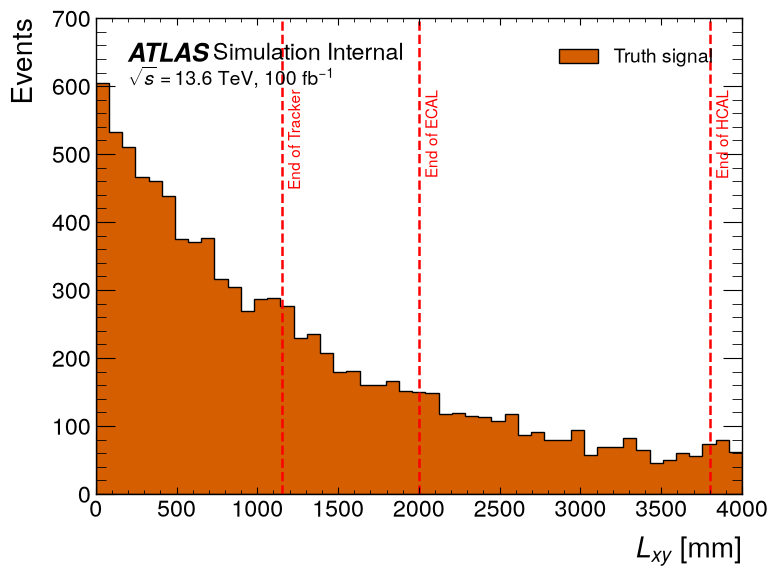

In [13]:
import matplotlib.pyplot as plt
import mplhep as hep

# ATLAS style
hep.style.use("ATLAS")

# Flatten the awkward array
lxy_flat = ak.to_numpy(ak.flatten(lxy)) #jagged arrays must be flatten

fig, ax = plt.subplots(figsize=(8, 6))

# Histogram
ax.hist(
    lxy_flat,
    bins=np.linspace(0, 4000,50),   # 0 to 4 meters
    histtype="stepfilled",
    edgecolor="black",
    linewidth=1,
    label="Truth signal"
)

# Detector boundaries in Radii
tracker = 1150   # mm
ecal    = 2000   # mm
hcal    = 3800   # mm

# Vertical reference lines
for x, label in [
    (tracker, "End of Tracker"),
    (ecal,    "End of ECAL"),
    (hcal,    "End of HCAL"),
]:
    ax.axvline(
        x,
        color="red",
        linestyle="--",
        linewidth=1.8,
    )

    ax.text(
        x+40,
        0.85,
        label,
        color="red",
        rotation=90,
        va="top",
        ha="left",
        transform=ax.get_xaxis_transform(),
        fontsize=11,
    )

# Labels
ax.set_xlabel(r"$L_{xy}$ [mm]")
ax.set_ylabel("Events")

# ATLAS label
hep.atlas.label(
    "Internal",
    data=False,
    lumi=100, #random for e.g
    com=13.6,
    ax=ax,
)

ax.legend(frameon=False)

plt.tight_layout()

## Example 2: Retrieving columns from DAODs stored on `/eos/`

We just retrieved signal features from an Rucio dataset stored on the grid. However, ServiceX dataset lookup utilities also include `fsspec` and `xRootD` allowing you to query an sample stored on some analysis group space under the `/eos/atlas` path. 


In [14]:
#Two other useful utilities in the side library
from servicex_analysis_utils import get_structure, ds_type_resolver

In [15]:
# file stored in a common /eos analysis space
eos_path = "/eos/atlas/atlascerngroupdisk/phys-exotics/ueh/ANA-EXOT-2023-04_A3LP/DAOD_LLP1/mc23_13p6TeV.604615.PhPy8EG_AZNLO_ggH125_mA0p4_Ctau25p0.deriv.DAOD_LLP1.e8601_s4159_r15530_p7073/DAOD_LLP1.47255118._000005.pool.root.1"
daod_dataset = ds_type_resolver(eos_path)

Although UprootRaw cannot extract xAOD object features like in ATLAS software, many features can be read by `uproot` when pointing to the correct branches.

For e.g `xAOD_Jet_V1* j;  j->getAtribute(EMFraction..)` could be accessed via the `AntiKt4EMTopoJetsAuxDyn.EMFrac` branch

Using UprootRaw can still be useful if you need to study specific processes that have not been processed via CP tools such as (TopCP, EasyJet...)

### Using `get_structure` 
This function uses a predefined, specific query to send back the scanned structure of a file from your sample.  
It becomes a very important utility when building queries to verify what branches are available. Additionally, it produces a file metadata output if the `Metadata` tree is in the file.

Example looking for EMFrac branches in the DAOD below:

In [16]:
print(get_structure(daod_dataset, filter_branch = "EMFrac"))

Output()


---------------------------
📁 Sample: Dataset
---------------------------

File Metadata ℹ️ :

── amiTag: e8601_e8586_s4159_s4114_r15530_r15514_p7073
── beamEnergy: 6.8e+06
── beamType: collisions
── conditionsTag: OFLCOND-MC23-SDR-RUN3-02
── generatorsInfo: Powheg(v.08-04)+Pythia8(v.314)+EvtGen(v.2.2.1)
── geometryVersion: ATLAS-R3S-2021-03-02-00
── isDataOverlay: 0
── mcCampaign: mc23d
── mcProcID: 604615.0
── simFlavour: FullG4_QS

---------------------------

File structure with branch filter 🌿 'EMFrac':


🌳 Tree: ##Params;3
   ├── Branches:

🌳 Tree: ##Params;2
   ├── Branches:

🌳 Tree: ##Shapes;3
   ├── Branches:

🌳 Tree: ##Shapes;2
   ├── Branches:

🌳 Tree: ##Links;3
   ├── Branches:

🌳 Tree: ##Links;2
   ├── Branches:

🌳 Tree: MetaData
   ├── Branches:

🌳 Tree: MetaDataHdr
   ├── Branches:

🌳 Tree: MetaDataHdrForm
   ├── Branches:

🌳 Tree: CollectionTree
   ├── Branches:
   │   ├── AntiKt4EMPFlowJetsAuxDyn.EMFrac ; dtype: AsJagged(AsDtype('>f4'), header_bytes=10)
   │   ├── Ant

#### Building the query, configuring the request, and retrieving the result is exactly the same as the first example

In [17]:
#1 Tree name read by get_structure
tree_daod = "CollectionTree"

#2 get only the EMFrac branch
branch_daod = [
        "AntiKt4EMTopoJetsAuxDyn.EMFrac",
]
#3 no selection here 

In [18]:
# The cut parameter is optional
daod_uproot_query=query.UprootRaw([{
    'treename': tree_daod,
    'filter_name': branch_daod, 
        }])

In [19]:
config_daod = {
    'Sample': [{
        'Name': 'DAOD-uproot',
        'Dataset': daod_dataset,
        'Query': daod_uproot_query
    }]
}

In [20]:
# Send request to ServiceX server
daod_result = deliver(config_daod)

Output()

In [21]:
#Load into arrays
daod_array = to_awk(daod_result)["DAOD-uproot"]

No TeX to Unicode mapping for '\\__radicalbig__'.
No TeX to Unicode mapping for '\\__radicalbig__'.
No TeX to Unicode mapping for '\\__radicalbig__'.
No TeX to Unicode mapping for '\\__radicalbig__'.


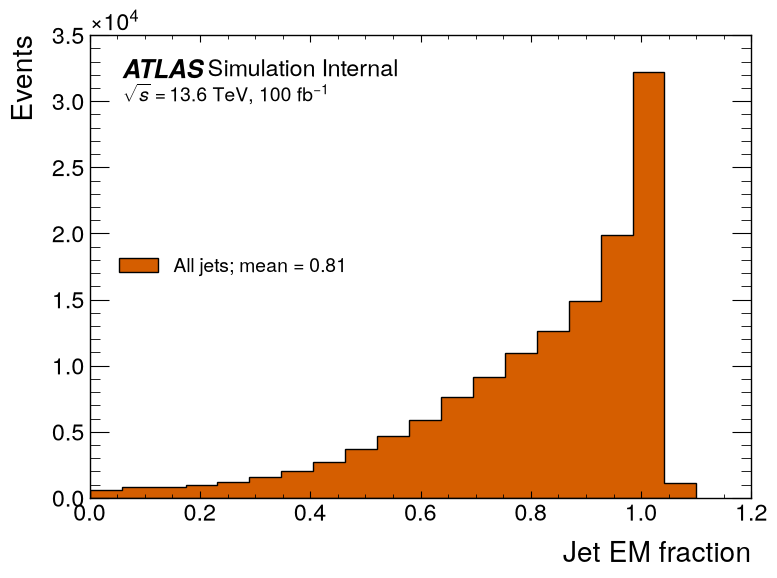

In [22]:
# ATLAS style
hep.style.use("ATLAS")

# Flatten the awkward array
em_frac= ak.to_numpy(ak.flatten(daod_array["AntiKt4EMTopoJetsAuxDyn.EMFrac"])) #jagged arrays must be flatten

fig, ax = plt.subplots(figsize=(8, 6))

# Histogram
ax.hist(
    em_frac,
    bins=np.linspace(0, 1.1, 20),  
    histtype="stepfilled",
    edgecolor="black",
    linewidth=1,
    label=f"All jets; mean = {np.mean(em_frac):.2f}"
)

# Labels
ax.set_xlabel("Jet EM fraction")
ax.set_ylabel("Events")

# ATLAS label
hep.atlas.label(
    "Internal",
    data=False,
    lumi=100, #random for e.g
    com=13.6,
    ax=ax,
)

ax.legend(frameon=False)

plt.tight_layout()

## Exercise: Plot the di-electron invariant mass
#### You will need to build a ServiceX query that:
1) retrieves the electron's mass and pT branches
2) Selects events with 2 electrons
3) Selects events where the charge of 2 electrons is opposite
4) Make two queries, one per dataset, in a single delivery request

Then manipulate your objects with `awkward`, build the invariant mass, and plot it in ATLAS style with `mplhep`

Use `get_structure` to identify the needed branches. (disclaimer: filter_branch does not take wildcards yet and is case-sensitive)

Hint: you can use the `vector` package

## Solution:

In [24]:
# Solution DAOD
daod_selection_sol = [
    "ElectronsAuxDyn.pt",
    "ElectronsAuxDyn.m",
    "ElectronsAuxDyn.charge",
    "ElectronsAuxDyn.eta",
    "ElectronsAuxDyn.phi"
]

# Event selection
# - Exactly 2 electrons
# - Opposite charge (sum of charges = 0)
daod_mask_sol = (
    '(num(ElectronsAuxDyn.pt) == 2) '
    '& (sum(ElectronsAuxDyn.charge) == 0)'
)

daod_query_sol = query.UprootRaw([{
    "treename": "CollectionTree",
    "filter_name": daod_selection_sol,
    "cut": daod_mask_sol,
}])

In [124]:
# Solution Ntuple
ntuple_sol = [
    "el_pt_NOSYS",
    "el_m_NOSYS",
    "el_charge",
    "el_eta",
    "el_phi"
]

# Event selection
# - Exactly 2 electrons
# - Opposite charge (sum of charges = 0)
ntuple_mask_sol = (
    '(num(el_m_NOSYS) == 2) '
    '& (sum(el_charge) == 0)'
)

ntuple_query_sol = query.UprootRaw([{
    "treename": "reco",
    "filter_name": ntuple_sol,
    "cut": ntuple_mask_sol,
}])

In [125]:
config_sol = {
    'Sample': [
        {
        'Name': 'test-sol-daod',
        'Dataset': daod_dataset,
        'Query': daod_query_sol
    },
        {
        'Name': 'test-sol-ntuple',
        'Dataset': request_DS,
        'Query': ntuple_query_sol
    }
    ]
}

In [126]:
sol_result = deliver(config_sol)

Output()

In [129]:
sol_arrays = to_awk(sol_result)
daod_array = sol_arrays['test-sol-daod']
ntuple_array = sol_arrays['test-sol-ntuple']

In [134]:
import vector

p4 = vector.zip({
    "pt": daod_array["ElectronsAuxDyn.pt"],
    "eta": daod_array["ElectronsAuxDyn.eta"],
    "phi": daod_array["ElectronsAuxDyn.phi"],
    "mass": daod_array["ElectronsAuxDyn.m"],
})

# Invariant mass of the electron pair
m_ee_daod = ak.to_numpy((p4[:, 0] + p4[:, 1]).mass) / 1_000


#Ntuple file

# Leading electron
pt1  = ntuple_array["el_pt_NOSYS"][:, 0]
eta1 = ntuple_array["el_eta"][:, 0]
phi1 = ntuple_array["el_phi"][:, 0]
m1   = ntuple_array["el_m_NOSYS"][:, 0]

# Subleading electron
pt2  = ntuple_array["el_pt_NOSYS"][:, 1]
eta2 = ntuple_array["el_eta"][:, 1]
phi2 = ntuple_array["el_phi"][:, 1]
m2   = ntuple_array["el_m_NOSYS"][:, 1]

# Cartesian components
px1 = pt1 * np.cos(phi1)
py1 = pt1 * np.sin(phi1)
pz1 = pt1 * np.sinh(eta1)
E1  = np.sqrt(px1**2 + py1**2 + pz1**2 + m1**2)

px2 = pt2 * np.cos(phi2)
py2 = pt2 * np.sin(phi2)
pz2 = pt2 * np.sinh(eta2)
E2  = np.sqrt(px2**2 + py2**2 + pz2**2 + m2**2)

# Sum the four-vectors
E  = E1 + E2
px = px1 + px2
py = py1 + py2
pz = pz1 + pz2

# Invariant mass
m_ee_ntuple = ak.to_numpy(np.sqrt(E**2 - px**2 - py**2 - pz**2)) / 1_000

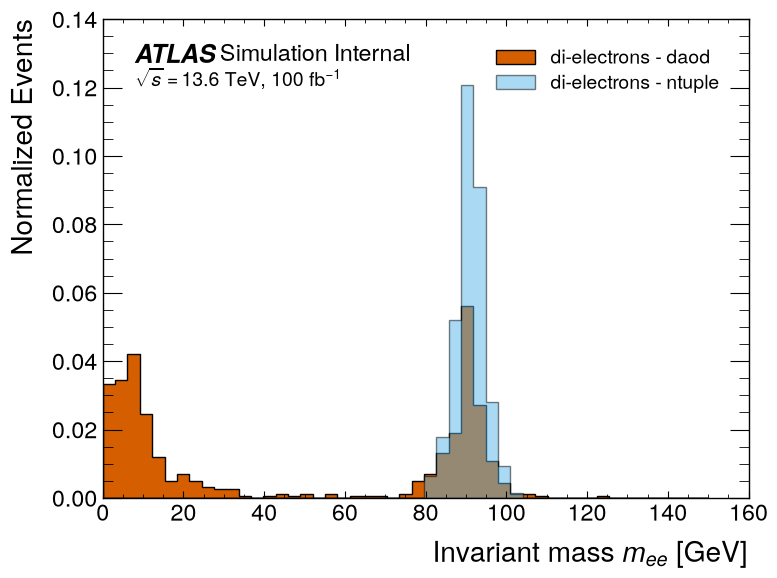

In [142]:
fig, ax = plt.subplots(figsize=(8, 6))

# Histogram
ax.hist(
    m_ee_daod,
    bins=np.linspace(0, 150, 50),
    density=True,
    histtype="stepfilled",
    edgecolor="black",
    linewidth=1,
    label="di-electrons - daod"
)

ax.hist(
    m_ee_ntuple,
    bins=np.linspace(0, 150, 50),
    density=True,
    histtype="stepfilled",
    edgecolor="black",
    linewidth=1,
    alpha=0.5,
    label="di-electrons - ntuple"
)


# Labels
ax.set_xlabel(r"Invariant mass $m_{ee}$ [GeV]")
ax.set_ylabel("Normalized Events")

# ATLAS label
hep.atlas.label(
    "Internal",
    data=False,
    lumi=100,
    com=13.6,
    ax=ax,
)

ax.legend(frameon=False)

plt.tight_layout()